## Script fusion dataset

In [1]:
import pandas as pd

print("Chargement des données...")
aisles = pd.read_csv('./datasets/aisles.csv')
departments = pd.read_csv('./datasets/departments.csv')
products = pd.read_csv('./datasets/products.csv')
orders = pd.read_csv('./datasets/orders.csv')
order_products = pd.read_csv('./datasets/order_products.csv') 

print("Fusion en cours...")
products_enriched = products.merge(aisles, on='aisle_id', how='left')
products_enriched = products_enriched.merge(departments, on='department_id', how='left')

orders_details = order_products.merge(orders, on='order_id', how='left')

df_master = orders_details.merge(products_enriched, on='product_id', how='left')

print("Fusion terminée !")
display(df_master.head())
print(f"Dimensions du dataset final : {df_master.shape}")

Chargement des données...
Fusion en cours...
Fusion terminée !


,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120.0,1.0,1.0,202279.0,3.0,5.0,9.0,8.0,NaN,Organic Egg Whites,86.0,16.0,eggs,dairy eggs
1,2,28985.0,2.0,1.0,202279.0,3.0,5.0,9.0,8.0,NaN,Michigan Organic Kale,83.0,4.0,fresh vegetables,produce
2,2,9327.0,3.0,0.0,202279.0,3.0,5.0,9.0,8.0,NaN,Garlic Powder,104.0,13.0,spices seasonings,pantry
3,2,45918.0,4.0,1.0,202279.0,3.0,5.0,9.0,8.0,NaN,Coconut Butter,19.0,13.0,oils vinegars,pantry
4,2,30035.0,5.0,0.0,202279.0,3.0,5.0,9.0,8.0,NaN,Natural Sweetener,17.0,13.0,baking ingredients,pantry


Dimensions du dataset final : (13692886, 15)


## Peak Days

Nombre de commandes par jour :
order_dow
0.0       9608
1.0       5213
2.0       3189
3.0       2280
4.0       2345
5.0       4062
6.0      12997
7.0      38687
8.0      75137
9.0     109220
10.0    122020
11.0    119964
12.0    114884
13.0    117439
14.0    119428
15.0    119754
16.0    115372
17.0     96566
18.0     77587
19.0     59275
20.0     43848
21.0     32721
22.0     26100
23.0     16725
Name: count, dtype: int64


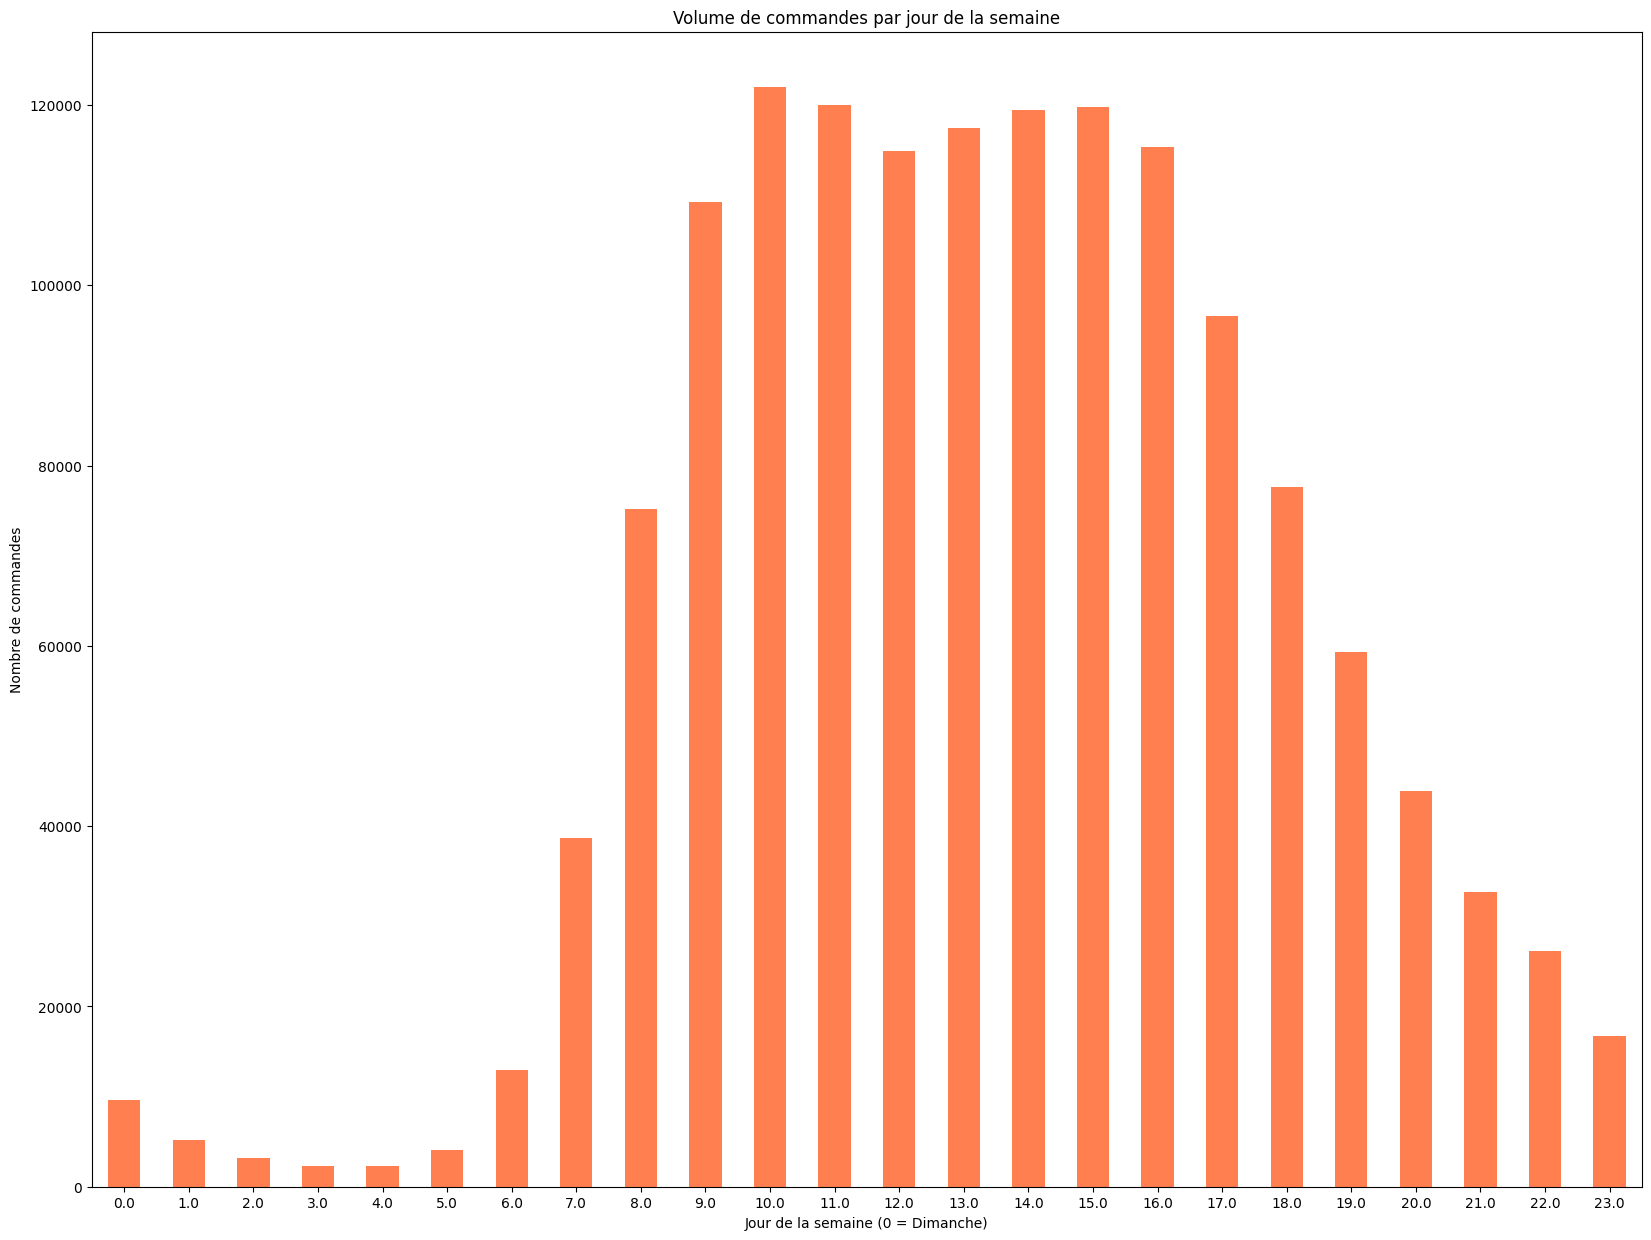

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

orders = pd.read_csv('./datasets/orders.csv')

peak_days = orders['order_dow'].value_counts().sort_index()

print("Nombre de commandes par jour :")
print(peak_days)

peak_days.plot(kind='bar', color='coral', figsize=(20, 15))
plt.title('Volume de commandes par jour de la semaine')
plt.xlabel('Jour de la semaine (0 = Dimanche)')
plt.ylabel('Nombre de commandes')
plt.xticks(rotation=0)
plt.show()

----------------------------------------------------------

## Product to buy before all customers buy it

## Chargement des datas

In [3]:
import pandas as pd
print("chargement des données")
order = pd.read_csv('./datasets/orders.csv')
order_products = pd.read_csv('./datasets/order_products.csv')

chargement des données


## On joins les produits commandés avec le jour de la commande (order_dow)

In [4]:
print("Analyse des Ventes par jour")

Analyse des Ventes par jour


## On prend que les collones utiles de 'orders' pour éco la mémoire RAM

In [5]:
df_sales = order_products[['order_id', 'product_id']].merge(orders[['order_id', 'order_dow']],
on='order_id', how='left')

## Calculer le nombre total de ventes par produit

In [6]:
##dd = (df_sales[["products_id", "products_name"]].head())
total_sales = df_sales.groupby('product_id').size().reset_index(name='total sales')
display(total_sales)

,product_id,total sales
0,1.0,773
1,2.0,37
2,3.0,94
3,4.0,149
4,5.0,6
...,...,...
49062,49684.0,5
49063,49685.0,19
49064,49686.0,49
49065,49687.0,4


## Calculer le nombre total de ventes spécifiquement le week-end

In [7]:
weekend_sales = df_sales[df_sales['order_dow'].isin([0.0, 1.0])]
weekend_sales_count = weekend_sales.groupby('product_id').size().reset_index(name='weekend_sales')
display(weekend_sales)
display(weekend_sales_count)

,order_id,product_id,order_dow
187,47,16797.0,0.0
188,47,39275.0,0.0
189,47,43352.0,0.0
190,47,46041.0,0.0
191,47,29223.0,0.0
...,...,...,...
13692263,2999940,644.0,1.0
13692264,2999940,12162.0,1.0
13692265,2999940,38861.0,1.0
13692266,2999940,19131.0,1.0


,product_id,weekend_sales
0,1.0,9
1,3.0,2
2,4.0,2
3,7.0,1
4,10.0,13
...,...,...
19166,49680.0,5
19167,49682.0,2
19168,49683.0,473
19169,49685.0,1


## Fusionner pour comparer le total et le Week-end

In [8]:
target_df = total_sales.merge(weekend_sales_count, on='product_id', how='left')
display(target_df)

,product_id,total sales,weekend_sales
0,1.0,773,9.0
1,2.0,37,NaN
2,3.0,94,2.0
3,4.0,149,2.0
4,5.0,6,NaN
...,...,...,...
49062,49684.0,5,NaN
49063,49685.0,19,1.0
49064,49686.0,49,1.0
49065,49687.0,4,NaN


## Si un produit n'a jamais été vendu le week-end, on remplace le vide (NaN) par 0

In [9]:
target_df['weekend_sales'] = target_df['weekend_sales'].fillna(0)

## Calculer le pourcentage des ventes du weekend (ratio)

In [10]:
target_df['weekend_ratio'] = (target_df['weekend_sales'] / target_df['total sales']).fillna(0)

## On crée la variable cible donc target
## On prend un seuil de 40% -> (0.40)

In [11]:
seuil = 0.40
target_df['is_weekend_bestseller'] = (target_df['weekend_ratio'] >= seuil).astype(int)


## Afficher les 10 premiers résultats

In [12]:
print("\n Aperçu des  produits")
display(target_df.head(10))


 Aperçu des  produits


,product_id,total sales,weekend_sales,weekend_ratio,is_weekend_bestseller
0,1.0,773,9.0,0.011643,0
1,2.0,37,0.0,0.000000,0
2,3.0,94,2.0,0.021277,0
3,4.0,149,2.0,0.013423,0
4,5.0,6,0.0,0.000000,0
5,6.0,3,0.0,0.000000,0
6,7.0,16,1.0,0.062500,0
7,8.0,69,0.0,0.000000,0
8,9.0,68,0.0,0.000000,0
9,10.0,1090,13.0,0.011927,0


## Aficher la répartition des classes (Produits 1 vs 0)

In [13]:
print("\n Répartition de la cible" )
print(target_df['is_weekend_bestseller'].value_counts(normalize=True) * 100)


 Répartition de la cible
is_weekend_bestseller
0    99.828806
1     0.171194
Name: proportion, dtype: float64


------------------------------------------------------------------

## Which products have the highest probability of being reordered?

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, roc_auc_score,
                              RocCurveDisplay, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
import warnings

warnings.filterwarnings('ignore')
print("ça charge...")
aisles = pd.read_csv('./datasets/aisles.csv')
departments = pd.read_csv('./datasets/departments.csv')
products = pd.read_csv('./datasets/products.csv')
orders = pd.read_csv('./datasets/orders.csv')
order_products = pd.read_csv('./datasets/order_products.csv') 

print(f"order_products: {order_products.shape[0]:,} lignes")
print(f"orders: {orders.shape[0]:,} lignes")
print(f"products: {products.shape[0]:,} lignes")

ça charge...
order_products: 13,692,886 lignes
orders: 1,444,444 lignes
products: 49,688 lignes


In [15]:
products_stats = (
    order_products.groupby('product_id').agg(
        total_orders = ('order_id', 'count'),
        reorder_count = ('reordered', 'sum'),
        avg_cart_position = ('add_to_cart_order', 'mean'),
        min_cart_position = ('add_to_cart_order', 'min'),
    )
    .reset_index()
)
products_stats['reorder_rate'] = products_stats['reorder_count']
products_stats['total_orders']

median_rate = products_stats['reorder_rate'].median()
products_stats['high_reorder'] = (products_stats['reorder_rate'] >= median_rate).astype(int)

user_count = (
    order_products
    .merge(orders[['order_id', 'user_id']], on='order_id')
    .groupby('product_id')['user_id']
    .nunique()
    .reset_index(name='unique_users')
)
products_stats = products_stats.merge(user_count, on='produc_id', how='left')
#on rattache aisle et département
product_full = (
    products
    .merge(orders, on='order_id')
    .merge(orders, on='departement_id')
    .merge(orders, on='product_id', how='inner')
)
#flag products bio
product_full['is_organic'] = product_full['product_name'].str.lower().str.contains('organic').astype(int)
print("features construites -->")
print(product_full[['product_name', 'department', 'total_orders', 'reorder_rate',
                 'avg_cart_position', 'unique_users', 'is_organic', 'high_reorder']].head())
print(f"\nDataset produits : {product_full.shape[0]:,} produits")
print(f"Médiane du taux de réachat (seuil) : {median_rate:.3f}")
print(f"Répartition de la cible :\n{product_full['high_reorder'].value_counts(normalize=True).mul(100).round(1).to_string()}")


KeyError: 'produc_id'